<a href="https://colab.research.google.com/github/AdyashaGiri/Vendor-Invoice-Intelligence-System-focused-on-Freight-Cost-Prediction-Invoice-Risk-Flagging/blob/main/Predicting_Freight_Cost_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import sqlite3

# 1. Connect to the fresh database file with (1) in its name
conn = sqlite3.connect("inventory (1).db")

# 2. Get the list of all tables
tables = pd.read_sql_query("select name from sqlite_master where type='table'", conn)

# 3. Loop through each table and display the first 5 rows
for table in tables['name']:
    print('Table name:', table)
    df = pd.read_sql_query(f"select * from {table} limit 5", conn)
    display(df)
    print("-" * 50)

Table name: purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


--------------------------------------------------
Table name: purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


--------------------------------------------------
Table name: vendor_invoice


...

--------------------------------------------------
Table name: begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


--------------------------------------------------
Table name: end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


--------------------------------------------------


In [ ]:
vendor_df=pd.read_sql_query("select * from vendor_invoice", conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [ ]:
vendor_df[['Quantity','Freight','Dollars']].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


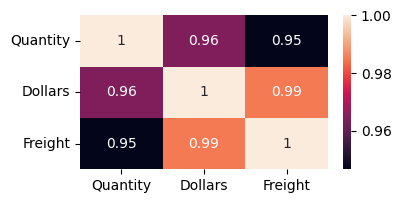

In [ ]:
# Relationship between Quantity, Dollars and Freight

import matplotlib.pyplot as plt
import seaborn as sns

# Relationship between Quantity, Dollars and Freight
plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity','Dollars','Freight']].corr(), annot=True)
plt.show()

# ... rest of your plotting code

In [ ]:
vendor_df['freight_per_unit'] = vendor_df['Freight']/vendor_df['Quantity']

In [ ]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [ ]:
low_quantity

np.float64(83.0)

In [ ]:
high_quantity

np.float64(5100.5)

In [ ]:
vendor_df.loc[vendor_df['Quantity']<low_quantity,'freight_per_unit'].mean()

np.float64(0.09489854253138316)

In [ ]:
vendor_df.loc[vendor_df['Quantity']>high_quantity,'freight_per_unit'].mean()

np.float64(0.049077654690759046)

In [ ]:
#features
x=vendor_df[['Quantity','Dollars']]
#target
y=vendor_df['Freight']

In [ ]:
vendor_df.describe().round()

,VendorNumber,PONumber,Quantity,Dollars,Freight,freight_per_unit
count,5543.0,5543.0,5543.0,5543.0,5543.0,5543.0
mean,20663.0,10889.0,6059.0,58073.0,296.0,0.0
std,34582.0,1601.0,14453.0,140234.0,714.0,0.0
min,2.0,8106.0,1.0,4.0,0.0,0.0
25%,3089.0,9504.0,83.0,968.0,5.0,0.0
50%,7240.0,10890.0,423.0,4765.0,25.0,0.0
75%,10754.0,12276.0,5100.0,44587.0,230.0,0.0
max,201359.0,13661.0,141660.0,1660436.0,8468.0,3.0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
model1=LinearRegression()
model1.fit(x_train,y_train)

model2=DecisionTreeRegressor(max_depth=4,random_state=42)
model2.fit(x_train,y_train)

model3=RandomForestRegressor(random_state=42)
model3.fit(x_train,y_train)

RandomForestRegressor(random_state=42)

In [ ]:
import numpy as np

def evaluate_model(model, x_test, y_test, model_name):
    preds = model.predict(x_test)

    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, preds)*100

    print(f"\n{model_name} Performance:")
    print(f"MAE   : {mae:.2f}")
    print(f"RMSE  : {rmse:.2f}")
    print(f"R²    : {r2:.2f}%")

In [ ]:
evaluate_model(model1, x_test, y_test, "Linear Regression")
evaluate_model(model2, x_test, y_test, "Decision Regression")
evaluate_model(model3, x_test, y_test, "Random Forest Regression")


Linear Regression Performance:
MAE   : 24.46
RMSE  : 124.43
R²    : 97.00%

Decision Regression Performance:
MAE   : 38.12
RMSE  : 138.25
R²    : 96.30%

Random Forest Regression Performance:
MAE   : 27.65
RMSE  : 138.62
R²    : 96.28%


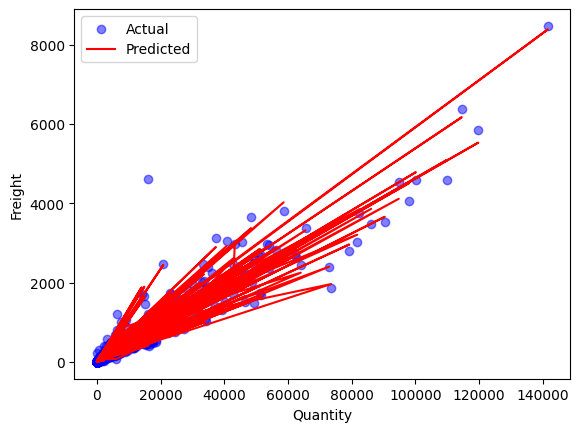

In [ ]:

plt.scatter(x_test['Quantity'], y_test, color='blue', alpha=0.5, label='Actual')
plt.plot(x_test['Quantity'], model1.predict(x_test), color='red', label='Predicted')

plt.xlabel('Quantity')
plt.ylabel('Freight')
plt.legend()
plt.show()

In [ ]:
# Create input data with a placeholder for Quantity
input_data = {
    "Quantity": [0, 0],
    "Dollars": [18500, 9000]
}

df = pd.DataFrame(input_data)

# Make sure the columns match the exact order they were trained in
# If the model expects Quantity first:
df = df[['Quantity', 'Dollars']]

model1.predict(df)

array([102.06789264,  52.53282862])

In [ ]:
# 1. This instantly creates the data_preprocessing.py file inside your folder
open('freight_cost_predict/data_preprocessing.py', 'w').close()

# 2. This forces Colab to open that file in the editor panel on the right side
from google.colab import files
import os
if os.path.exists('freight_cost_predict/data_preprocessing.py'):
    from google.colab import text
    text.edit('freight_cost_predict/data_preprocessing.py')

ImportError: cannot import name 'text' from 'google.colab' (/usr/local/lib/python3.12/dist-packages/google/colab/__init__.py)